<a href="https://colab.research.google.com/github/MIL-Project2/OCC-HVAC_IPYNB/blob/main/Occupancy_Training_15min.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GitHub Setup

In [1]:
import os
import sys

# ==========================================
# GITHUB SETUP
# ==========================================
from google.colab import userdata
PAT = userdata.get('GITHUB_PAT')

GITHUB_ORG = "MIL-Project2"
GITHUB_REPO = "OCC-HVAC_15"
BRANCH = "main" # Change to 'master' if your default branch is master

# Construct the authenticated repo URL
REPO_URL = f"https://{PAT}@github.com/{GITHUB_ORG}/{GITHUB_REPO}.git"
REPO_PATH = f"/content/{GITHUB_REPO}"

# 1. Clone the repository if it doesn't exist, otherwise pull latest changes
if not os.path.exists(REPO_PATH):
    print(f"Cloning repository into {REPO_PATH}...")
    !git clone {REPO_URL} {REPO_PATH}
else:
    print("Repository already exists. Pulling latest changes...")
    %cd {REPO_PATH}
    !git pull

# 2. Change the working directory to the repo so imports work
%cd {REPO_PATH}
sys.path.append(REPO_PATH)

# 3. Verify the feature engineering file is present
print("\nFiles in current directory:")
print(os.listdir(REPO_PATH))
print("\nSetup complete. You can now run the rest of the notebook.")

Cloning repository into /content/OCC-HVAC_15...
Cloning into '/content/OCC-HVAC_15'...
remote: Enumerating objects: 52, done.
remote: Counting objects: 100% (52/52), done.
remote: Compressing objects: 100% (51/51), done.
remote: Total 52 (delta 22), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (52/52), 608.19 KiB | 4.54 MiB/s, done.
Resolving deltas: 100% (22/22), done.
/content/OCC-HVAC_15

Files in current directory:
['run_simulation_cli.py', 'Occupancy_Inference.py', 'occupancy_model_15min.pkl', 'occupancy_model_15min_config.json', 'Occupancy-Prediction_Generated_Ver_1_3.csv', '.git', 'streamlit_app.py', 'requirements.txt', 'Occupancy_Training_15min.ipynb', 'README.md', 'feature_engineering.py', 'hvac_simulation.py']

Setup complete. You can now run the rest of the notebook.


# Occupancy Prediction — Training (15-Minute-Ahead Forecast)

Trains the occupancy model and saves it for inference elsewhere.

**This notebook only trains.** It has no simulation code. The saved
outputs (`occupancy_model_15min.pkl` + `occupancy_model_15min_config.json`)
are consumed by `Occupancy_Inference.py` and, through it, by
`streamlit_app.py`.

Feature engineering itself lives in `feature_engineering.py`, imported
below — the exact same function is used by the inference code, so
training and production compute features identically.

In [ ]:
# ── Core Libraries ──────────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# ── Scikit-learn ─────────────────────────────────────────────────────────────
from sklearn.base import clone
from sklearn.model_selection import cross_val_score, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import joblib
import json

!pip install optuna lightgbm xgboost --quiet
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

from lightgbm import LGBMRegressor
from xgboost import XGBRegressor

# Shared feature-engineering pipeline -- the SAME module Occupancy_Inference.py
# imports, so training and inference can never silently drift apart.
from feature_engineering import (
    build_features, split_features_target,
    MODEL_FEATURES, TARGET_COLUMN, FORECAST_HORIZON_MIN, TIME_RESOLUTION_MIN
)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 110

print('Libraries loaded. Optuna version:', optuna.__version__)
print(f'Model features ({len(MODEL_FEATURES)}):', MODEL_FEATURES)
print('Target:', TARGET_COLUMN, f'({FORECAST_HORIZON_MIN} minutes ahead)')

# This notebook trains the 15-minute-ahead model. FORECAST_HORIZON_MIN and
# TARGET_COLUMN are set inside feature_engineering.py (the shared module also
# used by Occupancy_Inference.py), so the horizon here isn't a local knob --
# it must be 15 there too, or this assertion stops the run before training on
# the wrong target.
EXPECTED_HORIZON_MIN = 15
assert FORECAST_HORIZON_MIN == EXPECTED_HORIZON_MIN, (
    f"feature_engineering.FORECAST_HORIZON_MIN is {FORECAST_HORIZON_MIN}, "
    f"expected {EXPECTED_HORIZON_MIN}. Update FORECAST_HORIZON_MIN (and the "
    "target column it derives, e.g. 'headcount_target_15min') in "
    "feature_engineering.py before training the 15-minute-ahead model."
)

Libraries loaded. Optuna version: 5.0.0
Model features (9): ['headcount', 'headcount_rolling_15min', 'headcount_trend', 'is_weekend_future', 'working_weekday_hour_future', 'hour_sin_future', 'hour_cos_future', 'day_sin_future', 'day_cos_future']
Target: headcount_target_15min (15 minutes ahead)


## 1. Load Raw Data

In [ ]:
# Mount Google Drive (a permissions popup will appear the first time
# this runs in a session -- approve it, then re-run this cell if needed).
from google.colab import drive
drive.mount('/content/drive')

RAW_DATA_PATH = '/content/drive/MyDrive/data/Occupancy-Prediction_Ver_1_3.csv'
raw_df = pd.read_csv(RAW_DATA_PATH)

print("Raw data shape:", raw_df.shape)
display(raw_df.head())

column_info = pd.DataFrame({
    'Data Type': raw_df.dtypes,
    'Non-Null Count': raw_df.count(),
    'Missing Values': raw_df.isnull().sum(),
    'Missing (%)': (raw_df.isnull().sum() / len(raw_df) * 100).round(2)
})
display(column_info)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Raw data shape: (54759, 6)


,collecteddate,floorspaceid,headcount,temperature,humidity,co2
0,2024-07-08 05:27:44+10,9f902aab-58fe-4b1c-ab24-241310df1550,1,NaN,NaN,NaN
1,2024-07-08 05:28:42+10,9f902aab-58fe-4b1c-ab24-241310df1550,0,NaN,NaN,NaN
2,2024-07-08 05:29:04+10,9f902aab-58fe-4b1c-ab24-241310df1550,0,NaN,NaN,NaN
3,2024-07-08 05:40:44+10,9f902aab-58fe-4b1c-ab24-241310df1550,1,NaN,NaN,NaN
4,2024-07-08 05:41:22+10,9f902aab-58fe-4b1c-ab24-241310df1550,0,NaN,NaN,NaN


,Data Type,Non-Null Count,Missing Values,Missing (%)
collecteddate,object,54759,0,0.0
floorspaceid,object,54759,0,0.0
headcount,int64,54759,0,0.0
temperature,float64,0,54759,100.0
humidity,float64,0,54759,100.0
co2,float64,0,54759,100.0


## 2. Feature Engineering (shared module)

`build_features()` parses timestamps, resamples onto a regular
5-minute grid, adds the backward-looking occupancy features, and adds
the forward-looking (but still leakage-free) calendar features for the
forecast target time. See `feature_engineering.py` for the full
docstring.

In [ ]:
features_df = build_features(raw_df)

print("Engineered features shape:", features_df.shape)
display(features_df[['target_time', 'forecast_time'] + MODEL_FEATURES + [TARGET_COLUMN]].head(10))

n_warmup = features_df['headcount_rolling_15min'].isna().sum()
n_no_future = features_df[TARGET_COLUMN].isna().sum()
print(
    f"\nRows that will be dropped before training -- "
    f"rolling-window warm-up: {n_warmup}, no future target yet: {n_no_future}"
)

Engineered features shape: (27439, 19)


,target_time,forecast_time,headcount,headcount_rolling_15min,headcount_trend,is_weekend_future,working_weekday_hour_future,hour_sin_future,hour_cos_future,day_sin_future,day_cos_future,headcount_target_15min
0,2024-07-08 05:30:00,2024-07-08 05:45:00,0.0,NaN,NaN,0,0,0.965926,2.588190e-01,0.0,1.0,1.0
1,2024-07-08 05:35:00,2024-07-08 05:50:00,0.0,NaN,NaN,0,0,0.965926,2.588190e-01,0.0,1.0,1.0
2,2024-07-08 05:40:00,2024-07-08 05:55:00,1.0,NaN,0.0,0,0,0.965926,2.588190e-01,0.0,1.0,1.0
3,2024-07-08 05:45:00,2024-07-08 06:00:00,1.0,0.333333,1.0,0,0,1.000000,6.123234e-17,0.0,1.0,1.0
4,2024-07-08 05:50:00,2024-07-08 06:05:00,1.0,0.666667,0.0,0,0,1.000000,6.123234e-17,0.0,1.0,1.0
5,2024-07-08 05:55:00,2024-07-08 06:10:00,1.0,1.000000,0.0,0,0,1.000000,6.123234e-17,0.0,1.0,1.0
6,2024-07-08 06:00:00,2024-07-08 06:15:00,1.0,1.000000,0.0,0,0,1.000000,6.123234e-17,0.0,1.0,1.0
7,2024-07-08 06:05:00,2024-07-08 06:20:00,1.0,1.000000,0.0,0,0,1.000000,6.123234e-17,0.0,1.0,1.0
8,2024-07-08 06:10:00,2024-07-08 06:25:00,1.0,1.000000,0.0,0,0,1.000000,6.123234e-17,0.0,1.0,1.0
9,2024-07-08 06:15:00,2024-07-08 06:30:00,1.0,1.000000,0.0,0,0,1.000000,6.123234e-17,0.0,1.0,1.0



Rows that will be dropped before training -- rolling-window warm-up: 3, no future target yet: 3


## 3. Quick EDA

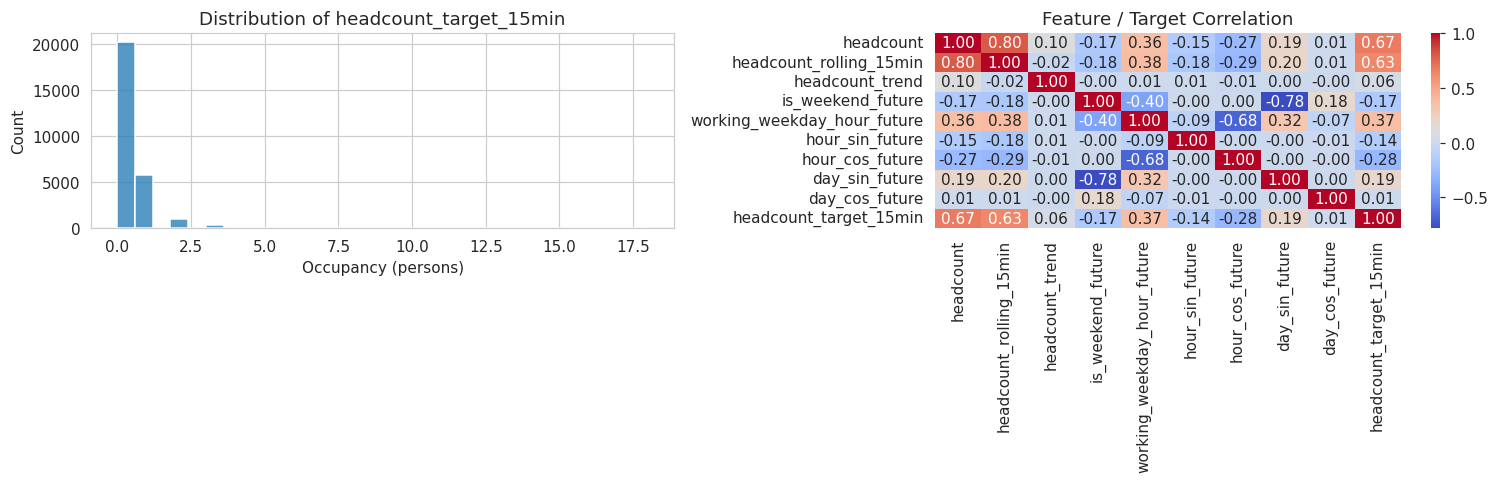

In [ ]:
model_data_preview = features_df.dropna(subset=MODEL_FEATURES + [TARGET_COLUMN])

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

sns.histplot(model_data_preview[TARGET_COLUMN], bins=30, ax=axes[0])
axes[0].set_title(f'Distribution of {TARGET_COLUMN}')
axes[0].set_xlabel('Occupancy (persons)')

corr_cols = MODEL_FEATURES + [TARGET_COLUMN]
sns.heatmap(
    model_data_preview[corr_cols].corr(), annot=True, fmt='.2f',
    cmap='coolwarm', ax=axes[1]
)
axes[1].set_title('Feature / Target Correlation')

plt.tight_layout()
plt.show()

## 4. Train/Test Split (chronological, 80/20)

In [ ]:
model_data = (
    features_df
    .dropna(subset=MODEL_FEATURES + [TARGET_COLUMN])
    .sort_values('target_time')
    .reset_index(drop=True)
)

split_idx = int(len(model_data) * 0.8)
train_data = model_data.iloc[:split_idx].copy()
test_data = model_data.iloc[split_idx:].copy()

X_train, y_train = train_data[MODEL_FEATURES], train_data[TARGET_COLUMN]
X_test, y_test = test_data[MODEL_FEATURES], test_data[TARGET_COLUMN]

print("=== DATA SPLIT (15-minute-ahead forecasting) ===")
print(f"Total data : {len(model_data):,}")
print(f"Train data : {len(train_data):,} ({len(train_data)/len(model_data)*100:.1f}%)")
print(f"Test data  : {len(test_data):,} ({len(test_data)/len(model_data)*100:.1f}%)")

print("\n=== TRAIN PERIOD ===")
print(train_data['target_time'].min(), "->", train_data['target_time'].max())

print("\n=== TEST PERIOD ===")
print(test_data['target_time'].min(), "->", test_data['target_time'].max())

print("\n=== SHAPE ===")
print("X_train:", X_train.shape, " y_train:", y_train.shape)
print("X_test :", X_test.shape, " y_test :", y_test.shape)

=== DATA SPLIT (15-minute-ahead forecasting) ===
Total data : 27,433
Train data : 21,946 (80.0%)
Test data  : 5,487 (20.0%)

=== TRAIN PERIOD ===
2024-07-08 05:45:00 -> 2024-09-22 10:30:00

=== TEST PERIOD ===
2024-09-22 10:35:00 -> 2024-10-11 11:45:00

=== SHAPE ===
X_train: (21946, 9)  y_train: (21946,)
X_test : (5487, 9)  y_test : (5487,)


## 5. Baseline Models

In [ ]:
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ],
    remainder='passthrough'
)

baseline_models = {
    'LightGBM': Pipeline(steps=[('preprocessor', preprocessor),
                                ('regressor', LGBMRegressor(random_state=RANDOM_STATE, verbose=-1))]),
    'XGBoost': Pipeline(steps=[('preprocessor', preprocessor),
                               ('regressor', XGBRegressor(random_state=RANDOM_STATE, verbosity=0))]),
    'Random Forest': Pipeline(steps=[('preprocessor', preprocessor),
                                      ('regressor', RandomForestRegressor(random_state=RANDOM_STATE))]),
    'Neural Network': Pipeline(steps=[('preprocessor', preprocessor),
                                       ('regressor', MLPRegressor(random_state=RANDOM_STATE))]),
    # NOTE: sklearn's LogisticRegression is a CLASSIFIER -- it cannot fit
    # this notebook's continuous target (headcount_target_15min) and would
    # raise "Unknown label type: continuous" if used here. LinearRegression
    # is the regression counterpart, so that's what's added below. See the
    # accompanying explanation for how to do true Logistic Regression if
    # you actually want occupancy_trend-style direction classification instead.
    'Linear Regression': Pipeline(steps=[('preprocessor', preprocessor),
                                          ('regressor', LinearRegression())]),
}

print("Baseline models initialized:")
for name, model in baseline_models.items():
    print(f"- {name}: {model}")

Baseline models initialized:
- LightGBM: Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer()),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['headcount',
                                                   'headcount_rolling_15min',
                                                   'headcount_trend',
                                                   'is_weekend_future',
                                                   'working_weekday_hour_future',
                                                   'hour_sin_future',
                                             

## 6. Baseline Training & Comparison


Training LightGBM...
  LightGBM - Training MAE: 0.2040, RMSE: 0.5022, R2: 0.5878
  LightGBM - Test MAE: 0.3056, RMSE: 0.6965, R2: 0.5197

Training XGBoost...
  XGBoost - Training MAE: 0.1848, RMSE: 0.4306, R2: 0.6969
  XGBoost - Test MAE: 0.3356, RMSE: 0.7986, R2: 0.3685

Training Random Forest...
  Random Forest - Training MAE: 0.1655, RMSE: 0.4018, R2: 0.7362
  Random Forest - Test MAE: 0.3379, RMSE: 0.7761, R2: 0.4036

Training Neural Network...
  Neural Network - Training MAE: 0.2356, RMSE: 0.5315, R2: 0.5384
  Neural Network - Test MAE: 0.3367, RMSE: 0.7009, R2: 0.5136

Training Linear Regression...
  Linear Regression - Training MAE: 0.2477, RMSE: 0.5771, R2: 0.4556
  Linear Regression - Test MAE: 0.3171, RMSE: 0.6688, R2: 0.5571


,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
Model,,,,,,
Linear Regression,0.2477,0.3171,0.5771,0.6688,0.4556,0.5571
LightGBM,0.2040,0.3056,0.5022,0.6965,0.5878,0.5197
Neural Network,0.2356,0.3367,0.5315,0.7009,0.5384,0.5136
Random Forest,0.1655,0.3379,0.4018,0.7761,0.7362,0.4036
XGBoost,0.1848,0.3356,0.4306,0.7986,0.6969,0.3685



Best baseline model (highest Test R2): Linear Regression (Test R2 = 0.557)


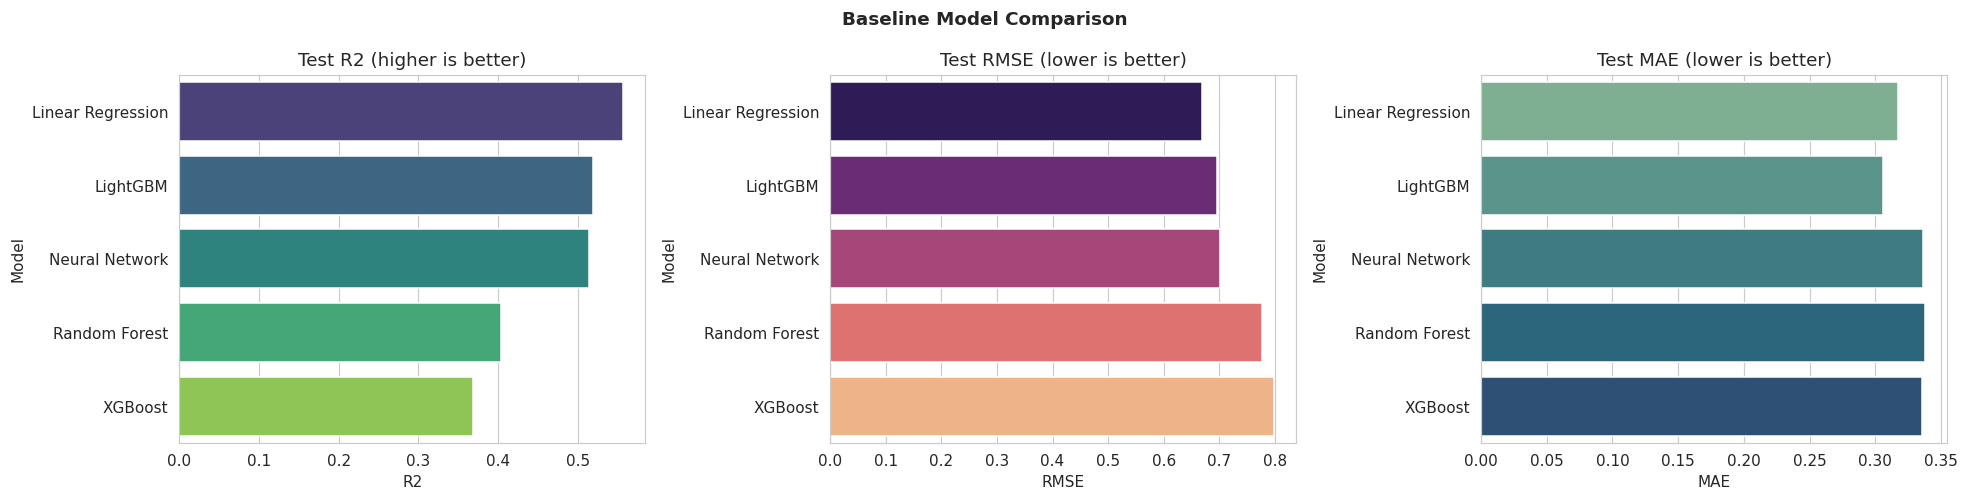

In [ ]:
import warnings
warnings.filterwarnings('ignore')

results = []

for name, model in baseline_models.items():
    print(f"\nTraining {name}...")
    model.fit(X_train, y_train)

    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)

    train_mae = mean_absolute_error(y_train, y_train_pred)
    test_mae = mean_absolute_error(y_test, y_test_pred)
    train_rmse = np.sqrt(mean_squared_error(y_train, y_train_pred))
    test_rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
    train_r2 = r2_score(y_train, y_train_pred)
    test_r2 = r2_score(y_test, y_test_pred)

    print(f"  {name} - Training MAE: {train_mae:.4f}, RMSE: {train_rmse:.4f}, R2: {train_r2:.4f}")
    print(f"  {name} - Test MAE: {test_mae:.4f}, RMSE: {test_rmse:.4f}, R2: {test_r2:.4f}")

    results.append({
        'Model': name,
        'Train MAE': train_mae, 'Test MAE': test_mae,
        'Train RMSE': train_rmse, 'Test RMSE': test_rmse,
        'Train R2': train_r2, 'Test R2': test_r2
    })

results_df = pd.DataFrame(results).sort_values(by='Test R2', ascending=False).set_index('Model')
display(results_df.round(4))

best_baseline = results_df.index[0]
print(f"\nBest baseline model (highest Test R2): {best_baseline} "
      f"(Test R2 = {results_df.loc[best_baseline, 'Test R2']:.3f})")

order = results_df.index
fig, axes = plt.subplots(1, 3, figsize=(18, 4.6))
sns.barplot(x=results_df['Test R2'], y=order, ax=axes[0], hue=order, palette='viridis', legend=False)
axes[0].set_title('Test R2 (higher is better)'); axes[0].set_xlabel('R2')
sns.barplot(x=results_df['Test RMSE'], y=order, ax=axes[1], hue=order, palette='magma', legend=False)
axes[1].set_title('Test RMSE (lower is better)'); axes[1].set_xlabel('RMSE')
sns.barplot(x=results_df['Test MAE'], y=order, ax=axes[2], hue=order, palette='crest', legend=False)
axes[2].set_title('Test MAE (lower is better)'); axes[2].set_xlabel('MAE')
plt.suptitle('Baseline Model Comparison', fontweight='bold')
plt.tight_layout(); plt.show()

## 7. Hyperparameter Tuning — Bayesian Optimisation with Time-Series CV

In [ ]:
def make_estimator_pipeline(estimator, scale_target=False):
    if scale_target:
        return Pipeline([('scaler', StandardScaler()), ('estimator', estimator)])
    else:
        return Pipeline([('estimator', estimator)])


def suggest_estimator(name, trial):
    if name == 'Random Forest':
        return RandomForestRegressor(
            n_estimators=trial.suggest_int('n_estimators', 50, 300, step=50),
            max_depth=trial.suggest_int('max_depth', 3, 30),
            min_samples_split=trial.suggest_int('min_samples_split', 2, 20),
            min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
            max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2', 1.0]),
            min_weight_fraction_leaf=trial.suggest_float('min_weight_fraction_leaf', 0.0, 0.5),
            bootstrap=trial.suggest_categorical('bootstrap', [True, False]),
            random_state=RANDOM_STATE,
            n_jobs=-1
        )
    elif name == 'Neural Network':
        return MLPRegressor(
            hidden_layer_sizes=trial.suggest_categorical(
                'hidden_layer_sizes',
                [(50,), (100,), (50, 50), (100, 50), (100, 100), (50, 25, 10)]
            ),
            activation=trial.suggest_categorical('activation', ['relu', 'tanh', 'logistic']),
            alpha=trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
            learning_rate_init=trial.suggest_float('learning_rate_init', 1e-4, 1e-1, log=True),
            learning_rate=trial.suggest_categorical('learning_rate', ['constant', 'invscaling', 'adaptive']),
            solver=trial.suggest_categorical('solver', ['adam', 'sgd']),
            momentum=trial.suggest_float('momentum', 0.8, 0.99) if trial.suggest_categorical('solver', ['adam', 'sgd']) == 'sgd' else 0.9,
            max_iter=1000,
            early_stopping=True,
            validation_fraction=0.15,
            n_iter_no_change=20,
            random_state=RANDOM_STATE
        )
    elif name == 'LightGBM':
        return LGBMRegressor(
            n_estimators=trial.suggest_int('n_estimators', 50, 500, step=50),
            max_depth=trial.suggest_int('max_depth', 3, 15),
            learning_rate=trial.suggest_float('learning_rate', 1e-3, 3e-1, log=True),
            num_leaves=trial.suggest_int('num_leaves', 15, 255),
            min_child_samples=trial.suggest_int('min_child_samples', 5, 100),
            subsample=trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
            reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbose=-1
        )
    elif name == 'XGBoost':
        return XGBRegressor(
            n_estimators=trial.suggest_int('n_estimators', 50, 500, step=50),
            max_depth=trial.suggest_int('max_depth', 3, 12),
            learning_rate=trial.suggest_float('learning_rate', 1e-3, 3e-1, log=True),
            subsample=trial.suggest_float('subsample', 0.5, 1.0),
            colsample_bytree=trial.suggest_float('colsample_bytree', 0.5, 1.0),
            min_child_weight=trial.suggest_int('min_child_weight', 1, 10),
            reg_alpha=trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
            reg_lambda=trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
            random_state=RANDOM_STATE,
            n_jobs=-1,
            verbosity=0
        )
    elif name == 'Linear Regression':
        # Plain OLS has essentially no hyperparameters worth Bayesian
        # tuning -- just these two boolean flags -- so this is included
        # mainly for structural consistency with the other models.
        return LinearRegression(
            fit_intercept=trial.suggest_categorical('fit_intercept', [True, False]),
            positive=trial.suggest_categorical('positive', [True, False])
        )


def rebuild_estimator(name, params):
    if name == 'Random Forest':
        return RandomForestRegressor(random_state=RANDOM_STATE, n_jobs=-1, **params)
    elif name == 'Neural Network':
        return MLPRegressor(
            max_iter=1000, early_stopping=True, validation_fraction=0.15,
            n_iter_no_change=20, random_state=RANDOM_STATE, **params
        )
    elif name == 'LightGBM':
        return LGBMRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbose=-1, **params)
    elif name == 'XGBoost':
        return XGBRegressor(random_state=RANDOM_STATE, n_jobs=-1, verbosity=0, **params)
    elif name == 'Linear Regression':
        return LinearRegression(**params)


# 5-fold time-series CV: each test fold is a block of consecutive
# samples, trained only on data that comes BEFORE it.
tscv = TimeSeriesSplit(n_splits=5)

tuning_config = {
    'Random Forest':     (False, 35),
    'Neural Network':    (True,  30),
    'LightGBM':          (False, 35),
    'XGBoost':           (False, 35),
    'Linear Regression': (False, 4),   # only fit_intercept x positive = 4 combos
}

best_params = {}
tuning_summary = []
best_models = {}
cv_scores = {}

print("=" * 80)
print("HYPERPARAMETER TUNING WITH BAYESIAN OPTIMIZATION")
print("USING TIME-SERIES CROSS-VALIDATION (5 SPLITS)")
print("=" * 80)

for name, (scale_target, n_trials) in tuning_config.items():
    print(f"\n{'='*80}\nTuning: {name}\nNumber of trials: {n_trials}\n{'-'*80}")

    def objective(trial, name=name, scale_target=scale_target):
        est = suggest_estimator(name, trial)
        pipeline = make_estimator_pipeline(est, scale_target=scale_target)
        scores = cross_val_score(pipeline, X_train, y_train, cv=tscv, scoring='r2', n_jobs=-1)
        return scores.mean()

    study = optuna.create_study(
        direction='maximize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=10, interval_steps=1)
    )
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    best_params[name] = study.best_params
    tuning_summary.append({
        'Model': name, 'Trials': n_trials, 'Best_CV_R2': round(study.best_value, 4),
    })

    print(f"\nBest 5-fold time-series CV R2 = {study.best_value:.4f}")
    print(f"  Best params: {study.best_params}")

    best_est = rebuild_estimator(name, study.best_params)
    best_pipeline = make_estimator_pipeline(best_est, scale_target=scale_target)
    fold_scores = cross_val_score(best_pipeline, X_train, y_train, cv=tscv, scoring='r2', n_jobs=-1)
    cv_scores[name] = fold_scores
    best_models[name] = best_pipeline
    tuning_summary[-1]['CV_R2_Std'] = round(fold_scores.std(), 4)

print("\n" + "=" * 80)
print("TUNING COMPLETE - SUMMARY (Time-Series CV)")
print("=" * 80)
summary_df = pd.DataFrame(tuning_summary).set_index('Model')
summary_df['CV_R2_Mean+/-Std'] = summary_df['Best_CV_R2'].astype(str) + ' +/- ' + summary_df['CV_R2_Std'].astype(str)
display(summary_df[['Trials', 'CV_R2_Mean+/-Std']])

print("\nBest hyperparameters:")
for name, params in best_params.items():
    print(f"\n{name}:")
    for k, v in params.items():
        print(f"  {k}: {v}")

HYPERPARAMETER TUNING WITH BAYESIAN OPTIMIZATION
USING TIME-SERIES CROSS-VALIDATION (5 SPLITS)

Tuning: Random Forest
Number of trials: 35
--------------------------------------------------------------------------------


  0%|          | 0/35 [00:00<?, ?it/s]


Best 5-fold time-series CV R2 = 0.4460
  Best params: {'n_estimators': 300, 'max_depth': 8, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 1.0, 'min_weight_fraction_leaf': 0.007186778507835646, 'bootstrap': True}

Tuning: Neural Network
Number of trials: 30
--------------------------------------------------------------------------------


  0%|          | 0/30 [00:00<?, ?it/s]


Best 5-fold time-series CV R2 = 0.4683
  Best params: {'hidden_layer_sizes': (100, 50), 'activation': 'logistic', 'alpha': 0.020257405805074284, 'learning_rate_init': 0.09664242215615974, 'learning_rate': 'constant', 'solver': 'sgd', 'momentum': 0.8671150893995606}

Tuning: LightGBM
Number of trials: 35
--------------------------------------------------------------------------------


...


Best 5-fold time-series CV R2 = 0.4431
  Best params: {'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.019038640103270724, 'subsample': 0.7044639369886002, 'colsample_bytree': 0.9293642546261681, 'min_child_weight': 5, 'reg_alpha': 1.2687739118428973e-06, 'reg_lambda': 2.796815441913811e-06}

Tuning: Linear Regression
Number of trials: 4
--------------------------------------------------------------------------------


  0%|          | 0/4 [00:00<?, ?it/s]


Best 5-fold time-series CV R2 = 0.4466
  Best params: {'fit_intercept': True, 'positive': False}

TUNING COMPLETE - SUMMARY (Time-Series CV)


,Trials,CV_R2_Mean+/-Std
Model,,
Random Forest,35,0.446 +/- 0.0712
Neural Network,30,0.4683 +/- 0.05
LightGBM,35,0.4529 +/- 0.0663
XGBoost,35,0.4431 +/- 0.0722
Linear Regression,4,0.4466 +/- 0.0495



Best hyperparameters:

Random Forest:
  n_estimators: 300
  max_depth: 8
  min_samples_split: 5
  min_samples_leaf: 4
  max_features: 1.0
  min_weight_fraction_leaf: 0.007186778507835646
  bootstrap: True

Neural Network:
  hidden_layer_sizes: (100, 50)
  activation: logistic
  alpha: 0.020257405805074284
  learning_rate_init: 0.09664242215615974
  learning_rate: constant
  solver: sgd
  momentum: 0.8671150893995606

LightGBM:
  n_estimators: 250
  max_depth: 3
  learning_rate: 0.024205055058002318
  num_leaves: 250
  min_child_samples: 19
  subsample: 0.8473221805752896
  colsample_bytree: 0.6217496443987012
  reg_alpha: 0.4647685957186775
  reg_lambda: 6.660834172057185e-07

XGBoost:
  n_estimators: 200
  max_depth: 3
  learning_rate: 0.019038640103270724
  subsample: 0.7044639369886002
  colsample_bytree: 0.9293642546261681
  min_child_weight: 5
  reg_alpha: 1.2687739118428973e-06
  reg_lambda: 2.796815441913811e-06

Linear Regression:
  fit_intercept: True
  positive: False


## 8. Final Comparison (Baseline vs Tuned)

In [ ]:
# NOTE on rounding: CV scoring above (and the "raw" Test metrics below)
# intentionally use each model's continuous predict() output, unrounded --
# that's the correct way to score/tune a regressor, and it's what Optuna's
# cross_val_score calls use internally. But Occupancy_Inference.py clips
# predictions to >= 0 and rounds them to the nearest whole person before
# they're ever shown to a user. So the "raw" metrics below describe the
# underlying model's continuous error, not the error you'll actually see
# in production. The "(Rounded)" columns apply that SAME clip+round step
# here, so you can see both side by side.
def round_like_inference(preds):
    return np.clip(preds, 0, None).round()

final_results = []
tuned_models = {}

for name in ['Random Forest', 'Neural Network', 'LightGBM', 'XGBoost', 'Linear Regression']:
    baseline_model = clone(baseline_models[name])
    baseline_cv = cross_val_score(baseline_model, X_train, y_train, cv=tscv, scoring='r2', n_jobs=-1)
    baseline_model.fit(X_train, y_train)
    baseline_pred = baseline_model.predict(X_test)
    baseline_test_r2 = r2_score(y_test, baseline_pred)
    baseline_test_mae = mean_absolute_error(y_test, baseline_pred)
    baseline_test_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
    baseline_pred_rounded = round_like_inference(baseline_pred)
    baseline_test_mae_rounded = mean_absolute_error(y_test, baseline_pred_rounded)
    baseline_test_rmse_rounded = np.sqrt(mean_squared_error(y_test, baseline_pred_rounded))

    tuned_estimator = rebuild_estimator(name, best_params[name])
    tuned_model = Pipeline([('preprocessor', clone(preprocessor)), ('regressor', tuned_estimator)])
    tuned_cv = cross_val_score(tuned_model, X_train, y_train, cv=tscv, scoring='r2', n_jobs=-1)
    tuned_model.fit(X_train, y_train)
    tuned_pred = tuned_model.predict(X_test)
    tuned_test_r2 = r2_score(y_test, tuned_pred)
    tuned_test_mae = mean_absolute_error(y_test, tuned_pred)
    tuned_test_rmse = np.sqrt(mean_squared_error(y_test, tuned_pred))
    tuned_pred_rounded = round_like_inference(tuned_pred)
    tuned_test_mae_rounded = mean_absolute_error(y_test, tuned_pred_rounded)
    tuned_test_rmse_rounded = np.sqrt(mean_squared_error(y_test, tuned_pred_rounded))

    tuned_models[name] = tuned_model

    final_results.append({
        'Model': name,
        'Baseline CV R2': baseline_cv.mean(), 'Tuned CV R2': tuned_cv.mean(),
        'Baseline Test R2': baseline_test_r2, 'Tuned Test R2': tuned_test_r2,
        'Baseline Test MAE': baseline_test_mae, 'Tuned Test MAE': tuned_test_mae,
        'Baseline Test RMSE': baseline_test_rmse, 'Tuned Test RMSE': tuned_test_rmse,
        'Baseline Test MAE (Rounded)': baseline_test_mae_rounded,
        'Tuned Test MAE (Rounded)': tuned_test_mae_rounded,
        'Baseline Test RMSE (Rounded)': baseline_test_rmse_rounded,
        'Tuned Test RMSE (Rounded)': tuned_test_rmse_rounded,
    })

final_comparison = pd.DataFrame(final_results).sort_values(by='Tuned Test R2', ascending=False).set_index('Model')
display(final_comparison.round(4))

,Baseline CV R2,Tuned CV R2,Baseline Test R2,Tuned Test R2,Baseline Test MAE,Tuned Test MAE,Baseline Test RMSE,Tuned Test RMSE,Baseline Test MAE (Rounded),Tuned Test MAE (Rounded),Baseline Test RMSE (Rounded),Tuned Test RMSE (Rounded)
Model,,,,,,,,,,,,
Linear Regression,0.4466,0.4466,0.5571,0.5571,0.3171,0.3171,0.6688,0.6688,0.2289,0.2289,0.6900,0.6900
LightGBM,0.3795,0.4526,0.5197,0.5539,0.3056,0.2898,0.6965,0.6712,0.2355,0.2245,0.7110,0.6950
Neural Network,0.4191,0.4683,0.5136,0.5504,0.3367,0.2843,0.7009,0.6738,0.2623,0.2227,0.7276,0.6936
XGBoost,0.2540,0.4433,0.3685,0.5321,0.3356,0.2942,0.7986,0.6874,0.2810,0.2213,0.8229,0.7069
Random Forest,0.3284,0.4460,0.4036,0.5256,0.3379,0.2865,0.7761,0.6921,0.2943,0.2231,0.7940,0.7159


## 9. Select & Save the Best Model

In [ ]:
best_model_name = final_comparison.index[0]
print(f"Best model based on Test R2: {best_model_name}")
print(f"Tuned Test R2: {final_comparison.loc[best_model_name, 'Tuned Test R2']:.4f}")
print(f"Tuned Test MAE: {final_comparison.loc[best_model_name, 'Tuned Test MAE']:.4f}")

best_tuned_model = tuned_models[best_model_name]

# Optional: retrain on the full dataset (train+test) before deploying,
# so the deployed model sees the most recent data too.
# X_full = pd.concat([X_train, X_test])
# y_full = pd.concat([y_train, y_test])
# best_tuned_model.fit(X_full, y_full)

MODEL_FILENAME = 'occupancy_model_15min.pkl'
joblib.dump(best_tuned_model, MODEL_FILENAME)
print(f"Model saved as '{MODEL_FILENAME}'")

feature_config = {
    'forecast_horizon_minutes': FORECAST_HORIZON_MIN,
    'time_resolution_minutes': TIME_RESOLUTION_MIN,
    'features': MODEL_FEATURES,
    'target': TARGET_COLUMN,
    'notes': (
        "Computed by feature_engineering.build_features(). 'headcount' and "
        "'headcount_rolling_15min' use ACTUAL occupancy up to and including "
        "the current timestamp; the '_future' calendar features use "
        f"(current timestamp + {FORECAST_HORIZON_MIN} minutes)."
    )
}

CONFIG_FILENAME = 'occupancy_model_15min_config.json'
with open(CONFIG_FILENAME, 'w') as f:
    json.dump(feature_config, f, indent=2)

print(f"Feature configuration saved as '{CONFIG_FILENAME}'")
print("\nThese two files are what Occupancy_Inference.py / streamlit_app.py load at inference time.")

Best model based on Test R2: Linear Regression
Tuned Test R2: 0.5571
Tuned Test MAE: 0.3171
Model saved as 'occupancy_model_15min.pkl'
Feature configuration saved as 'occupancy_model_15min_config.json'

These two files are what Occupancy_Inference.py / streamlit_app.py load at inference time.


## Next steps

- `Occupancy_Inference.py` loads `occupancy_model_15min.pkl` +
  `occupancy_model_15min_config.json` and runs prediction on newly
  uploaded raw data (no training code, no Optuna).
- `hvac_simulation.py` takes the resulting forecast and runs the 1R1C
  scheduled-vs-predictive HVAC comparison.
- `streamlit_app.py` wires both together behind a file upload.

# Push

In [ ]:
# # ==========================================
# # SAVE TO GITHUB
# # ==========================================
# # Configure Git (replace with your details)
# !git config --global user.email "jwas0006@student.monash.edu"
# !git config --global user.name "MIL-Project2"

# # The exact name of your notebook in Colab (check the tab at the top)
# NOTEBOOK_NAME = "Occupancy_Training_15min.ipynb"

# # Copy the notebook from Colab's root directory into the repo folder
# !cp /content/{NOTEBOOK_NAME} {REPO_PATH}/

# # Stage the notebook, model, and config files
# !git add {NOTEBOOK_NAME}
# !git add occupancy_model_15min.pkl
# !git add occupancy_model_15min_config.json

# # Commit and push
# !git commit -m "Update training notebook, model, and config from Colab"
# !git push origin {BRANCH}

# print(f"\nSuccessfully pushed {NOTEBOOK_NAME} and model artifacts to GitHub!")

In [ ]:
# import sklearn, numpy, pandas, joblib; print(sklearn.__version__, numpy.__version__, pandas.__version__, joblib.__version__)

## **Download pkl and json File**

In [ ]:
from google.colab import files

files.download('occupancy_model_15min.pkl')
files.download('occupancy_model_15min_config.json')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>